# 📈 TradeTutor v2 — 매수/매도 타이밍 · 손절/익절까지 (LangGraph)

Education Agent(트레이딩 학습) 확장판. **언제 사고 팔지, 어디서 익절·손절할지**를
실제 코인 데이터로 계산해 알려주고, *왜 그런지* 가르친다. ⚠️ 학습용 (투자 조언 아님)

## 요구사항 충족

| 요구 | 구현 |
|---|---|
| 노드 ≥3 | **6개**: `router` · `research` · `backtest` · `coach` · `tutor_agent` · `tools` |
| Conditional Edge ≥1 | **2개**: ① `router` → 학습 경로 vs 조언 경로 ② `tools_condition`(도구 호출 여부) |
| Tool ≥1 | **3개(커스텀)**: `analyze_timing`(진입·손절·익절) · `market_snapshot` · `web_search` |
| (보너스) 메모리 | `MemorySaver` 체크포인터 — thread 별 대화 기억 |
| (보너스) 멀티 툴 | 도구 3개 |

## 그래프 구조

```mermaid
graph TD
    S([사용자 입력]) --> RT[router 노드]
    RT -->|route=learn| RE[research]
    RE --> BT[backtest]
    BT --> CO[coach] --> E1([END])
    RT -->|route=advisor| TA[tutor_agent]
    TA -->|도구 호출| TL[tools<br/>analyze_timing / market_snapshot / web_search]
    TL --> TA
    TA -->|답변 완료| E2([END])
```

- **router** 가 입력을 분류 → *"전략을 배우고 싶다"* 는 학습 경로, *"지금 타이밍/손절익절/시장질문"* 은 조언 경로 (**Conditional Edge**)
- 조언 경로의 `tutor_agent` 는 `analyze_timing` **도구**로 실제 데이터 기반 진입/손절/익절을 계산 (**Tool + tools_condition**)
- `MemorySaver` 로 같은 대화(thread)에서 맥락 기억 (**메모리**)

---
## 코드

In [1]:
import dotenv
dotenv.load_dotenv()

from typing import TypedDict, Annotated, Literal
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt

from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph.message import add_messages
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage

plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False
print("준비 완료")

준비 완료


In [2]:
# ---------- 지표 + 5개 전략 + 데이터 + 백테스트 (v1 재사용) ----------
def _sma(s, n): return s.rolling(n).mean()
def _ema(s, n): return s.ewm(span=n, adjust=False).mean()
def _rsi(c, n=14):
    d = c.diff()
    up = d.clip(lower=0).ewm(alpha=1/n, adjust=False).mean()
    dn = (-d.clip(upper=0)).ewm(alpha=1/n, adjust=False).mean()
    return 100 - 100 / (1 + up / dn.replace(0, np.nan))
def _atr(df, n=14):
    tr = pd.concat([df.high - df.low,
                    (df.high - df.close.shift()).abs(),
                    (df.low - df.close.shift()).abs()], axis=1).max(axis=1)
    return tr.ewm(alpha=1/n, adjust=False).mean()
def _hold(entry, exit):
    e, x = entry.fillna(False), exit.fillna(False)
    pos = pd.Series(0, index=entry.index); h = 0
    for i in range(len(pos)):
        if h == 0 and e.iloc[i]: h = 1
        elif h == 1 and x.iloc[i]: h = 0
        pos.iloc[i] = h
    return pos

def sig_sma_cross(df, fast=20, slow=50):
    f, s = _sma(df.close, fast), _sma(df.close, slow)
    return ((f > s) & f.notna() & s.notna()).astype(int)
def sig_rsi(df, n=14, low=30, high=70): return _hold(_rsi(df.close, n) < low, _rsi(df.close, n) > high)
def sig_macd(df, fast=12, slow=26, sig=9):
    m = _ema(df.close, fast) - _ema(df.close, slow); sg = _ema(m, sig)
    pos = (m > sg).astype(int); pos[m.isna() | sg.isna()] = 0; return pos
def sig_bollinger(df, n=20, k=2):
    ma, sd = _sma(df.close, n), df.close.rolling(n).std()
    return _hold(df.close < (ma - k*sd), df.close > ma)
def sig_breakout(df, n=20):
    return _hold(df.close > df.close.rolling(n).max().shift(1), df.close < df.close.rolling(n).min().shift(1))

STRATEGY_LIBRARY = {
    "sma_cross": {"name": "골든/데드 크로스 (SMA 20/50)", "desc": "단기 이평이 장기 이평 상향 돌파 매수, 하향 돌파 매도. 추세추종.", "signal": sig_sma_cross},
    "rsi": {"name": "RSI 과매도/과매수 (14, 30/70)", "desc": "RSI 30 아래 매수, 70 위 매도. 평균회귀.", "signal": sig_rsi},
    "macd": {"name": "MACD 시그널 크로스 (12/26/9)", "desc": "MACD가 시그널선 상향 돌파 매수, 하향 돌파 매도.", "signal": sig_macd},
    "bollinger": {"name": "볼린저 밴드 (20, 2σ)", "desc": "하단밴드 이탈 매수, 중심선 회복 매도. 평균회귀.", "signal": sig_bollinger},
    "breakout": {"name": "돌파 (Donchian 20일)", "desc": "20일 고가 돌파 매수, 20일 저가 이탈 매도. 추세추종.", "signal": sig_breakout},
}

def fetch_ohlcv(symbol="BTCUSDT", interval="1d", limit=365):
    r = requests.get("https://api.binance.com/api/v3/klines",
                     params={"symbol": symbol, "interval": interval, "limit": limit}, timeout=20)
    r.raise_for_status()
    cols = ["open_time","open","high","low","close","volume","close_time","qav","trades","tbav","tbqav","ignore"]
    df = pd.DataFrame(r.json(), columns=cols)
    df["date"] = pd.to_datetime(df["open_time"], unit="ms")
    for c in ["open","high","low","close","volume"]: df[c] = df[c].astype(float)
    return df[["date","open","high","low","close","volume"]].set_index("date")

def run_backtest(df, position):
    pos = position.shift(1).fillna(0); ret = df.close.pct_change().fillna(0)
    equity = (1 + pos*ret).cumprod(); bh = (1 + ret).cumprod(); dd = equity/equity.cummax()-1
    c, p = df.close.values, pos.values; trades, entry = [], None
    for i in range(len(p)):
        if entry is None and p[i] == 1: entry = i
        elif entry is not None and p[i] == 0: trades.append(c[i]/c[entry]-1); entry = None
    if entry is not None: trades.append(c[-1]/c[entry]-1)
    wins = [t for t in trades if t > 0]
    return {"total_return": float(equity.iloc[-1]-1), "bh_return": float(bh.iloc[-1]-1),
            "mdd": float(dd.min()), "n_trades": len(trades),
            "win_rate": float(len(wins)/len(trades)) if trades else 0.0,
            "equity": equity, "bh_equity": bh, "position": pos, "df": df}
print("전략:", list(STRATEGY_LIBRARY))

전략: ['sma_cross', 'rsi', 'macd', 'bollinger', 'breakout']


In [3]:
# ================= 커스텀 도구 (Tool 연동) =================
@tool
def analyze_timing(symbol: str, strategy_key: str = "sma_cross") -> str:
    """지금 시점의 매수/매도 신호와 진입가·손절가·익절가를 실제 코인 데이터로 계산한다.
    Args:
        symbol: 코인 심볼 (예: BTCUSDT, ETHUSDT)
        strategy_key: 전략 (sma_cross/rsi/macd/bollinger/breakout)
    """
    try:
        if strategy_key not in STRATEGY_LIBRARY: strategy_key = "sma_cross"
        df = fetch_ohlcv(symbol, "1d", 200)
        pos = STRATEGY_LIBRARY[strategy_key]["signal"](df)
        price = float(df.close.iloc[-1]); atr = float(_atr(df).iloc[-1])
        signal = "🟢 매수/보유 구간 (진입 신호 켜짐)" if int(pos.iloc[-1]) == 1 else "⚪ 관망/현금 구간 (진입 신호 꺼짐)"
        sl, tp = price - 2*atr, price + 3*atr
        sup, res = float(df.low.iloc[-20:].min()), float(df.high.iloc[-20:].max())
        rr = (tp - price) / (price - sl)
        return (f"[{symbol} · {STRATEGY_LIBRARY[strategy_key]['name']}] 타이밍 분석 (학습용, 투자 조언 아님)\n"
                f"- 현재가: {price:,.2f}\n- 현재 신호: {signal}\n- 진입가(예시): {price:,.2f}\n"
                f"- 손절가: {sl:,.2f} ({(sl/price-1)*100:+.1f}%, ATR×2)\n"
                f"- 익절가: {tp:,.2f} ({(tp/price-1)*100:+.1f}%, ATR×3)\n"
                f"- 손익비(R:R): {rr:.2f} : 1\n- 최근 20일 지지 {sup:,.2f} / 저항 {res:,.2f}\n- ATR(14): {atr:,.2f}")
    except Exception as e:
        return f"타이밍 분석 실패: {e}"

@tool
def market_snapshot(symbol: str) -> str:
    """코인의 현재가, 24시간 변동률, 24시간 고저를 반환한다.
    Args:
        symbol: 코인 심볼 (예: BTCUSDT)
    """
    try:
        d = requests.get("https://api.binance.com/api/v3/ticker/24hr", params={"symbol": symbol}, timeout=15).json()
        return (f"{symbol} 현재가 {float(d['lastPrice']):,.2f} / 24h {float(d['priceChangePercent']):+.2f}% "
                f"/ 고 {float(d['highPrice']):,.2f} 저 {float(d['lowPrice']):,.2f}")
    except Exception as e:
        return f"시세 조회 실패: {e}"

@tool
def web_search(query: str) -> str:
    """인터넷에서 매매 전략·시장 정보를 검색한다.
    Args:
        query: 검색어
    """
    try:
        from ddgs import DDGS
        with DDGS() as d:
            res = list(d.text(query, max_results=3))
        return "\n".join(f"- {r.get('title','')}: {r.get('body','')[:160]}" for r in res) or "검색 결과 없음"
    except Exception as e:
        return f"웹 검색 사용 불가: {e}"

TOOLS = [analyze_timing, market_snapshot, web_search]
print("도구:", [t.name for t in TOOLS])

도구: ['analyze_timing', 'market_snapshot', 'web_search']


In [4]:
# ================= State + 모델 =================
class TradeTutorState(TypedDict):
    messages: Annotated[list, add_messages]
    route: str
    strategy_key: str
    symbol: str
    strategy_rules: str
    backtest_result: dict
    coaching: str

class RouteDecision(BaseModel):
    route: Literal["learn", "advisor"] = Field(description="learn=전략을 체계적으로 배우고 백테스트, advisor=지금 타이밍/손절익절/시장질문")
    strategy_key: str = Field(default="sma_cross", description="sma_cross/rsi/macd/bollinger/breakout 중 하나")
    symbol: str = Field(default="BTCUSDT", description="코인 심볼, 예 BTCUSDT")

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.3)
llm_tools = llm.bind_tools(TOOLS)

In [5]:
# ================= 노드 =================
def router_node(state: TradeTutorState):
    user = [m for m in state["messages"] if isinstance(m, HumanMessage)][-1].content
    prompt = f"""사용자 메시지를 분류해.
- learn: 특정 매매 전략을 처음부터 체계적으로 배우고 백테스트로 검증하고 싶을 때
- advisor: 지금 매수/매도 타이밍, 손절/익절 지점, 현재 시장 상황 등 실전 질문일 때
전략을 언급하면 strategy_key, 코인을 언급하면 symbol 도 뽑아. (기본 sma_cross / BTCUSDT)
메시지: {user}"""
    d = llm.with_structured_output(RouteDecision).invoke([HumanMessage(content=prompt)])
    return {"route": d.route, "strategy_key": d.strategy_key or "sma_cross", "symbol": (d.symbol or "BTCUSDT").upper()}

def research_node(state: TradeTutorState):
    strat = STRATEGY_LIBRARY[state["strategy_key"]]
    resp = llm.invoke([SystemMessage(content="트레이딩 교육 튜터"),
        HumanMessage(content=f"전략 '{strat['name']}' ({strat['desc']}) 을 진입규칙/청산규칙/핵심원리/주의점 형식으로 한국어로 간결히 가르쳐. 학습용.")])
    return {"strategy_rules": resp.content, "messages": [AIMessage(content=resp.content)]}

def backtest_node(state: TradeTutorState):
    key, symbol = state["strategy_key"], state["symbol"]
    df = fetch_ohlcv(symbol, "1d", 365)
    result = run_backtest(df, STRATEGY_LIBRARY[key]["signal"](df))
    summary = {k: result[k] for k in ["total_return","bh_return","mdd","n_trades","win_rate"]}
    summary["symbol"] = symbol   # State 는 메모리로 직렬화 → float 요약만 저장
    s = f"{symbol} · {STRATEGY_LIBRARY[key]['name']} → 전략 {summary['total_return']:.1%} / 보유 {summary['bh_return']:.1%} / MDD {summary['mdd']:.1%} / {summary['n_trades']}회 / 승률 {summary['win_rate']:.0%}"
    return {"backtest_result": summary, "messages": [AIMessage(content="📊 " + s)]}

def coach_node(state: TradeTutorState):
    r = state["backtest_result"]; name = STRATEGY_LIBRARY[state["strategy_key"]]["name"]
    resp = llm.invoke([SystemMessage(content="트레이딩 교육 튜터"),
        HumanMessage(content=f"{r['symbol']} 에 '{name}' 백테스트 결과(전략 {r['total_return']:.1%}, 보유 {r['bh_return']:.1%}, MDD {r['mdd']:.1%}, {r['n_trades']}회, 승률 {r['win_rate']:.0%})를 학습 관점에서 해석하고 강점/약점/다음 실험을 한국어로 코칭해.")])
    return {"coaching": resp.content, "messages": [AIMessage(content=resp.content)]}

TUTOR_SYS = SystemMessage(content=(
    "너는 트레이딩 학습 튜터야. 지금 매수/매도 타이밍이나 손절·익절 지점을 물으면 "
    "analyze_timing 도구로 '실제 데이터 기반' 진입가·손절가·익절가·손익비를 계산해서 알려주고, "
    "왜 그 지점인지(변동성 ATR, 지지/저항, 손익비) 반드시 가르쳐. 현재 시세는 market_snapshot, "
    "새 전략/개념은 web_search 를 써. 항상 한국어. 이건 학습용이지 투자 조언이 아님을 밝혀."))

def tutor_agent(state: TradeTutorState):
    return {"messages": [llm_tools.invoke([TUTOR_SYS] + state["messages"])]}

In [6]:
# ================= 그래프 (조건분기 + 도구 루프 + 메모리) =================
def route_after_router(state: TradeTutorState) -> str:
    return "research" if state["route"] == "learn" else "tutor_agent"

def build_app():
    g = StateGraph(TradeTutorState)
    g.add_node("router", router_node)
    g.add_node("research", research_node)
    g.add_node("backtest", backtest_node)
    g.add_node("coach", coach_node)
    g.add_node("tutor_agent", tutor_agent)
    g.add_node("tools", ToolNode(TOOLS))
    g.add_edge(START, "router")
    # Conditional Edge ①: 입력에 따라 학습 vs 조언 경로
    g.add_conditional_edges("router", route_after_router,
                            {"research": "research", "tutor_agent": "tutor_agent"})
    g.add_edge("research", "backtest"); g.add_edge("backtest", "coach"); g.add_edge("coach", END)
    # Conditional Edge ②: 도구 호출 여부
    g.add_conditional_edges("tutor_agent", tools_condition)
    g.add_edge("tools", "tutor_agent")
    return g.compile(checkpointer=MemorySaver())   # 메모리

app = build_app()
app.get_graph().print_ascii()

                  +-----------+                      
                  | __start__ |                      
                  +-----------+                      
                         *                           
                         *                           
                         *                           
                    +--------+                       
                    | router |                       
                    +--------+....                   
                  ...             ...                
                 .                   ....            
               ..                        ..          
      +-------------+                  +----------+  
      | tutor_agent |                  | research |  
      +-------------+                  +----------+  
         .        ..                         *       
       ..           ..                       *       
      .               ..                     *       
+-------+               .   

### 실행 A — 학습 경로 (Conditional Edge: `route=learn`)

*"골든크로스 배우고 싶어"* → router 가 **learn** 으로 분기 → `research → backtest → coach`

In [7]:
cfg_a = {"configurable": {"thread_id": "demo-learn"}}
a = app.invoke({"messages": [HumanMessage(content="골든크로스 전략 배우고 싶어")]}, cfg_a)
print("라우팅:", a["route"], "| 전략:", a["strategy_key"], "| 코인:", a["symbol"])
print("\n[규칙]\n", a["strategy_rules"][:400])
r = a["backtest_result"]
print(f"\n[백테스트] {r['symbol']} 전략 {r['total_return']:.1%} / 보유 {r['bh_return']:.1%} / MDD {r['mdd']:.1%} / {r['n_trades']}회 / 승률 {r['win_rate']:.0%}")
print("\n[코칭]\n", a["coaching"][:400])

라우팅: learn | 전략: sma_cross | 코인: BTCUSDT

[규칙]
 ### 골든/데드 크로스 (SMA 20/50) 전략

#### 1. 진입규칙
- **매수 신호 (골든 크로스)**: 20일 단기 이동평균선(SMA 20)이 50일 장기 이동평균선(SMA 50)을 상향 돌파할 때 매수.
- **매도 신호 (데드 크로스)**: 20일 단기 이동평균선(SMA 20)이 50일 장기 이동평균선(SMA 50)을 하향 돌파할 때 매도.

#### 2. 청산규칙
- **매수 포지션 청산**: SMA 20이 SMA 50을 하향 돌파할 때.
- **매도 포지션 청산**: SMA 20이 SMA 50을 상향 돌파할 때.

#### 3. 핵심 원리
- **추세 추종**: 이 전략은 시장의 추세를 따르는 방식으로, 상승 추세에서 매수하고 하락 추세에서 매도하여 수익을 추구합니다.
- **이동평균선*

[백테스트] BTCUSDT 전략 -14.3% / 보유 -45.7% / MDD -28.5% / 4회 / 승률 50%

[코칭]
 BTCUSDT의 '골든/데드 크로스 (SMA 20/50)' 전략에 대한 백테스트 결과를 분석해보겠습니다.

### 결과 해석
1. **전략 수익률: -14.3%**
   - 이 전략은 전체적으로 손실을 기록했습니다. 이는 시장의 전반적인 하락세나 전략의 적합성이 떨어졌음을 시사합니다.

2. **보유 수익률: -45.7%**
   - 장기 보유 전략이 더 큰 손실을 초래했습니다. 이는 시장이 하락세에 있었거나, 해당 자산의 기본적인 가치가 하락했음을 나타냅니다.

3. **MDD (Maximum Drawdown): -28.5%**
   - 최대 낙폭이 28.5%라는 것은 투자자가 경험할 수 있는 최대 손실이 상당히 크다는 것을 의미합니다. 이는 심리적 스트레스를 유발할 수 있으며, 자산의 변동성이 크다는 것


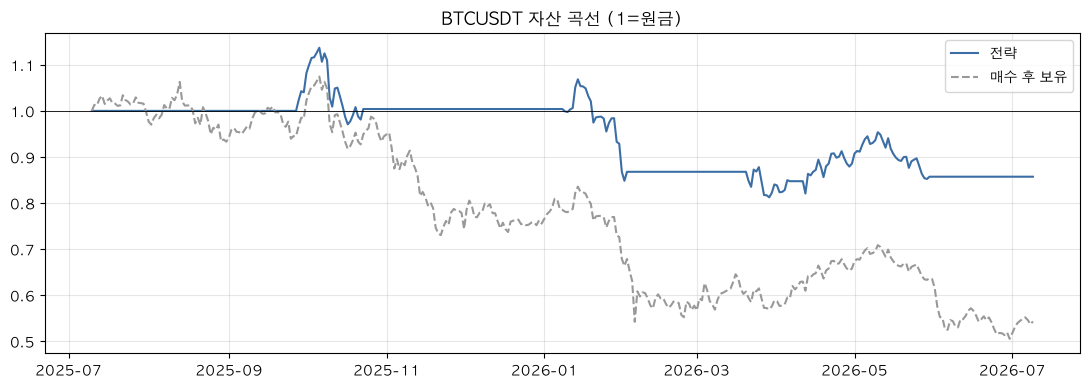

In [8]:
# 학습 경로 백테스트 차트 (State 밖에서 전체 결과 재계산 → 시각화)
res = run_backtest(fetch_ohlcv(a["symbol"], "1d", 365), STRATEGY_LIBRARY[a["strategy_key"]]["signal"](fetch_ohlcv(a["symbol"], "1d", 365)))
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(res["equity"].index, res["equity"], color="#3b6ea5", lw=1.5, label="전략")
ax.plot(res["bh_equity"].index, res["bh_equity"], color="#999", ls="--", label="매수 후 보유")
ax.axhline(1, color="k", lw=.6); ax.set_title(f"{a['symbol']} 자산 곡선 (1=원금)")
ax.legend(); ax.grid(alpha=.3); plt.tight_layout(); plt.show()

### 실행 B — 조언 경로 (Conditional Edge: `route=advisor` + **Tool** 호출) ⭐

*"지금 BTC 매수 타이밍이야? 손절·익절 어디?"* → router 가 **advisor** 로 분기 →
`tutor_agent` 가 `analyze_timing` **도구**를 호출해 **실제 데이터로 진입가·손절가·익절가**를 계산.

In [9]:
cfg_b = {"configurable": {"thread_id": "demo-advisor"}}
b = app.invoke({"messages": [HumanMessage(content="지금 비트코인(BTCUSDT) 골든크로스 기준으로 매수 타이밍이야? 손절이랑 익절은 어디에 둬야 해?")]}, cfg_b)
print("라우팅:", b["route"])
tools_used = [tc["name"] for m in b["messages"] if isinstance(m, AIMessage) for tc in (m.tool_calls or [])]
print("호출된 도구:", tools_used)
print("\n[튜터 답변]\n", b["messages"][-1].content)

라우팅: advisor
호출된 도구: ['analyze_timing']

[튜터 답변]
 현재 비트코인(BTCUSDT)의 골든크로스 기준으로 분석한 결과는 다음과 같습니다:

- **현재가**: 63,000.92 USDT
- **현재 신호**: ⚪ 관망/현금 구간 (진입 신호 꺼짐)

### 진입가, 손절가, 익절가
- **진입가**: 63,000.92 USDT (현재가)
- **손절가**: 58,685.80 USDT (-6.8%, ATR×2)
- **익절가**: 69,473.60 USDT (+10.3%, ATR×3)
- **손익비 (R:R)**: 1.50 : 1

### 분석 이유
1. **변동성 (ATR)**: 현재 ATR(14)은 2,157.56으로, 이는 최근 14일간의 평균 변동성을 나타냅니다. 손절가는 ATR의 2배를 기준으로 설정하여, 가격이 급락할 경우 손실을 최소화할 수 있도록 하였습니다.
   
2. **지지/저항**: 최근 20일 기준으로 지지선은 57,800.19 USDT, 저항선은 65,622.83 USDT입니다. 손절가는 지지선 아래에 설정하여 가격이 하락할 경우 손실을 방지하고, 익절가는 저항선 위에 설정하여 상승 시 이익을 극대화할 수 있도록 하였습니다.

현재는 매수 신호가 꺼져 있는 상태이므로, 관망하는 것이 좋습니다. 추가적인 매수 신호가 발생할 때까지 기다리는 것이 안전합니다.


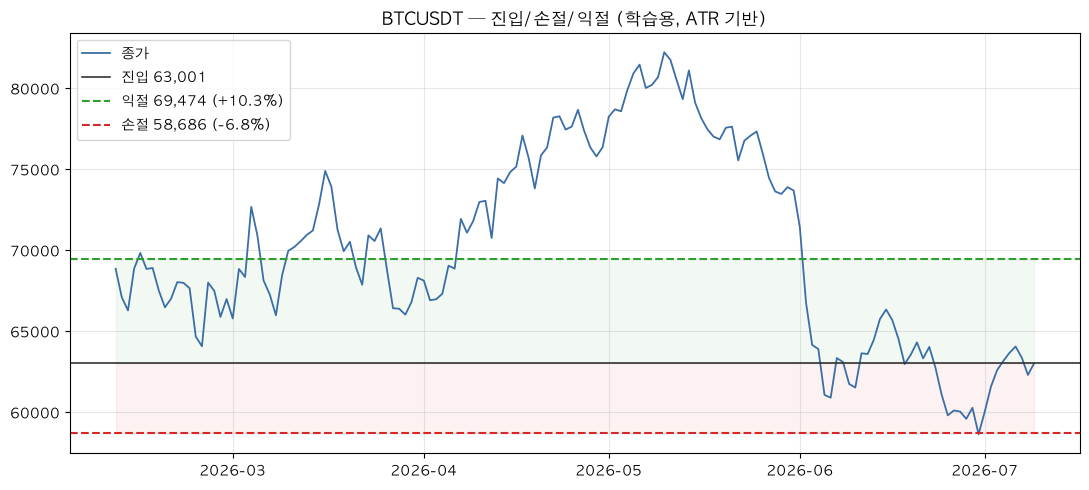

In [10]:
# 진입/손절/익절 시각화
def plot_timing(symbol, strategy_key="sma_cross", lookback=150):
    df = fetch_ohlcv(symbol, "1d", 200)
    price = float(df.close.iloc[-1]); atr = float(_atr(df).iloc[-1])
    sl, tp = price - 2*atr, price + 3*atr
    sub = df.iloc[-lookback:]
    fig, ax = plt.subplots(figsize=(11, 5))
    ax.plot(sub.index, sub.close, color="#3b6ea5", lw=1.3, label="종가")
    ax.axhline(price, color="#333", lw=1.2, label=f"진입 {price:,.0f}")
    ax.axhline(tp, color="#2ca02c", ls="--", lw=1.5, label=f"익절 {tp:,.0f} (+{(tp/price-1)*100:.1f}%)")
    ax.axhline(sl, color="#d62728", ls="--", lw=1.5, label=f"손절 {sl:,.0f} ({(sl/price-1)*100:.1f}%)")
    ax.fill_between(sub.index, price, tp, color="#2ca02c", alpha=.06)
    ax.fill_between(sub.index, sl, price, color="#d62728", alpha=.06)
    ax.set_title(f"{symbol} — 진입/손절/익절 (학습용, ATR 기반)")
    ax.legend(loc="upper left"); ax.grid(alpha=.3); plt.tight_layout(); plt.show()

plot_timing("BTCUSDT", "sma_cross")

### 실행 C — 메모리 (같은 thread 후속 질문)

같은 `thread_id` 에서 *"방금 그거 이더리움으로도"* → 앞의 맥락(골든크로스 타이밍)을 기억해 ETH 로 분석.

In [11]:
b2 = app.invoke({"messages": [HumanMessage(content="방금 그거 이더리움(ETHUSDT)으로도 알려줘")]}, cfg_b)
tools_used2 = [tc["name"] for m in b2["messages"] if isinstance(m, AIMessage) for tc in (m.tool_calls or [])]
print("이번 턴 호출 도구:", tools_used2)
print("\n[튜터 답변]\n", b2["messages"][-1].content[:500])
print("\n(이 thread 의 누적 메시지 수:", len(b2["messages"]), "→ 이전 대화를 기억하고 있음)")

이번 턴 호출 도구: ['analyze_timing', 'analyze_timing']

[튜터 답변]
 현재 이더리움(ETHUSDT)의 골든크로스 기준으로 분석한 결과는 다음과 같습니다:

- **현재가**: 1,742.41 USDT
- **현재 신호**: ⚪ 관망/현금 구간 (진입 신호 꺼짐)

### 진입가, 손절가, 익절가
- **진입가**: 1,742.41 USDT (현재가)
- **손절가**: 1,588.00 USDT (-8.9%, ATR×2)
- **익절가**: 1,974.03 USDT (+13.3%, ATR×3)
- **손익비 (R:R)**: 1.50 : 1

### 분석 이유
1. **변동성 (ATR)**: 현재 ATR(14)은 77.21로, 이는 최근 14일간의 평균 변동성을 나타냅니다. 손절가는 ATR의 2배를 기준으로 설정하여, 가격이 급락할 경우 손실을 최소화할 수 있도록 하였습니다.

2. **지지/저항**: 최근 20일 기준으로 지지선은 1,512.00 USDT, 저항선은 1,833.40 USDT입니다. 손절가는 지지선 아래에 설정하여 가격이 하락할 경우 손실

(이 thread 의 누적 메시지 수: 8 → 이전 대화를 기억하고 있음)


---
## 정리

- ✅ **노드 6개** — router / research / backtest / coach / tutor_agent / tools
- ✅ **Conditional Edge 2개** — ① 학습 vs 조언 라우팅 ② 도구 호출 여부(`tools_condition`)
- ✅ **Tool 3개(커스텀)** — `analyze_timing`(진입·손절·익절) / `market_snapshot` / `web_search`
- ✅ **메모리** — `MemorySaver` 로 thread 별 대화 기억
- 핵심: 실제 코인 데이터로 **매수/매도 타이밍 + 손절·익절 지점 + 손익비**를 계산하고, *왜 그런지*(ATR·지지/저항) 가르친다.

**다음 단계**: 자막·뉴스 리서치 노드, 사용자 리스크 성향 반영한 손절 폭 자동화, 여러 코인 동시 스캔.
